In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from pathlib import Path
from datasets import load_dataset

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.preprocessing import LabelEncoder

from transformers import (
    AutoTokenizer,
    AutoModel,
    get_linear_schedule_with_warmup
)
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torch.optim import AdamW

from tqdm import tqdm

In [5]:
DATASET_NAME = "Tobi-Bueck/customer-support-tickets"

def load_data():

    ds = load_dataset(DATASET_NAME)["train"]
    df = ds.to_pandas()

    return df
df = load_data()

def read_idx(path):
    return np.loadtxt(path, dtype=int)


def create_splits(df, data_dir="data"):

    train_idx = read_idx(Path(data_dir) / "train_idx.txt")
    val_idx = read_idx(Path(data_dir) / "val_idx.txt")
    test_idx = read_idx(Path(data_dir) / "test_idx.txt")

    splits = {
        "train": df.iloc[train_idx].copy(),
        "val": df.iloc[val_idx].copy(),
        "test": df.iloc[test_idx].copy(),
    }

    for split in splits:
        splits[split]["type"] = splits[split]["type"].fillna("Unknown")

    print("Train:", len(splits["train"]))
    print("Val:", len(splits["val"]))
    print("Test:", len(splits["test"]))

    return splits

splits = create_splits(df)
splits

Train: 49412
Val: 6176
Test: 6177


{'train':                                                  subject  \
 0                        Wesentlicher Sicherheitsvorfall   
 1                                     Account Disruption   
 2      Query About Smart Home System Integration Feat...   
 3                      Inquiry Regarding Invoice Details   
 4      Question About Marketing Agency Software Compa...   
 ...                                                  ...   
 61760     Assistance Needed for IFTTT Docker Integration   
 61761        Bitten um Unterstützung bei der Integration   
 61762                                               None   
 61763            Hilfe bei digitalen Strategie-Problemen   
 61764  Optimierung Ihrer Datenanalyse-Plattform erlei...   
 
                                                     body  \
 0      Sehr geehrtes Support-Team,\n\nich möchte eine...   
 1      Dear Customer Support Team,\n\nI am writing to...   
 2      Dear Customer Support Team,\n\nI hope this mes...   
 3      Dear 

# EDA

In [6]:
def plot_queue_distribution(df):

    counts = df["queue"].value_counts().sort_values(ascending=False)

    plt.figure(figsize=(14,6))

    sns.barplot(
        x=counts.index,
        y=counts.values,
        palette="viridis"
    )

    plt.xticks(rotation=90)
    plt.title("Queue class distribution")

    plt.ylabel("Count")
    plt.xlabel("Queue")

    plt.show()

def plot_priority_distribution(df):

    plt.figure(figsize=(6,4))

    sns.countplot(
        data=df,
        x="priority",
        palette="mako"
    )

    plt.title("Priority distribution")

    plt.show()

def plot_text_lengths(df):

    texts = df["subject"].fillna("") + " " + df["body"].fillna("")

    lengths = texts.str.len()

    plt.figure(figsize=(10,5))

    sns.histplot(lengths, bins=100)

    plt.title("Text length distribution")
    plt.xlabel("Characters")

    plt.show()

def plot_language_distribution(df):

    plt.figure(figsize=(5,4))

    sns.countplot(
        data=df,
        x="language"
    )

    plt.title("Language distribution")

    plt.show()

/tmp/ipykernel_453/2621009905.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


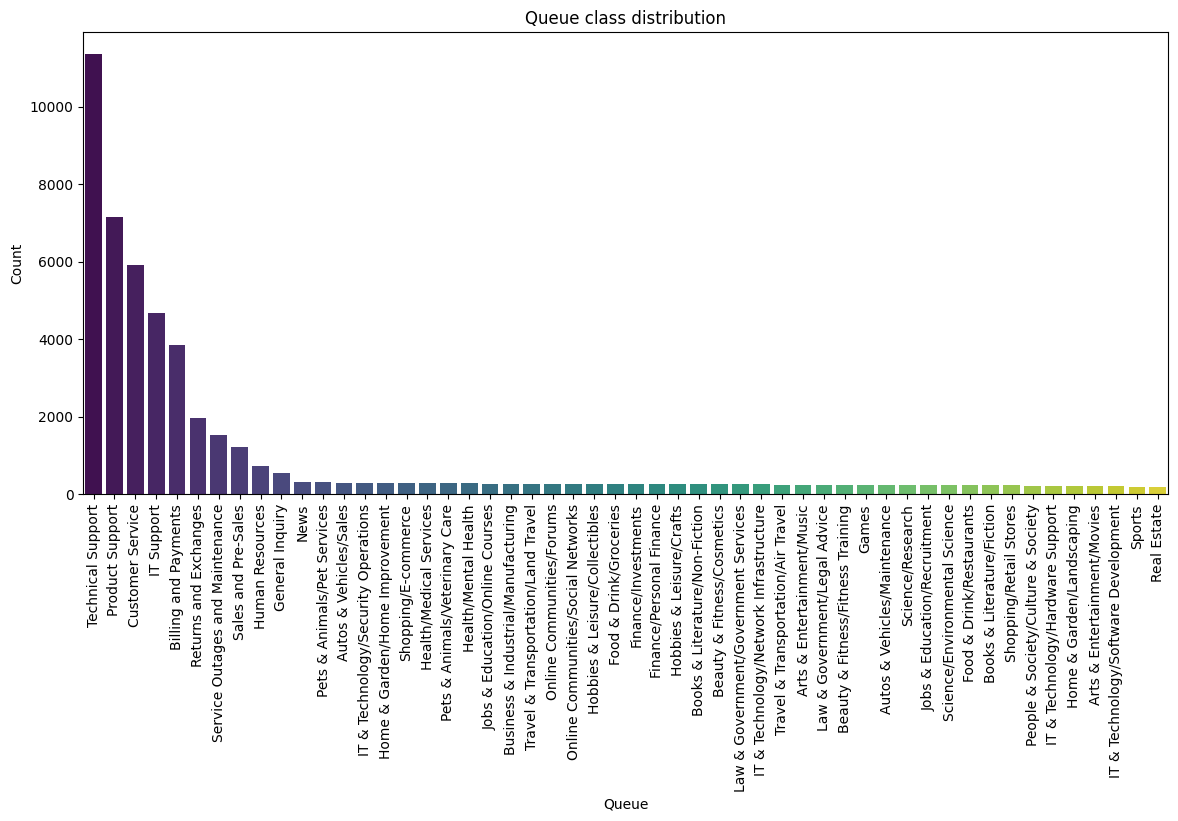

/tmp/ipykernel_453/2621009905.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


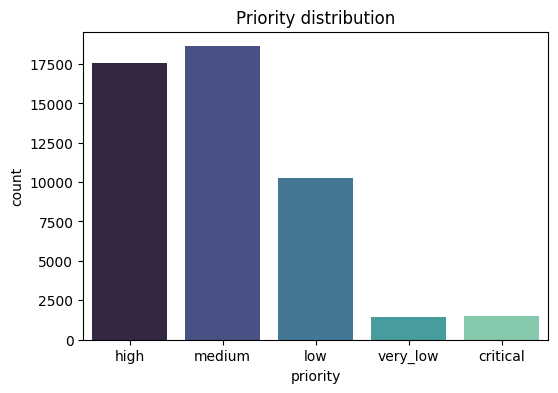

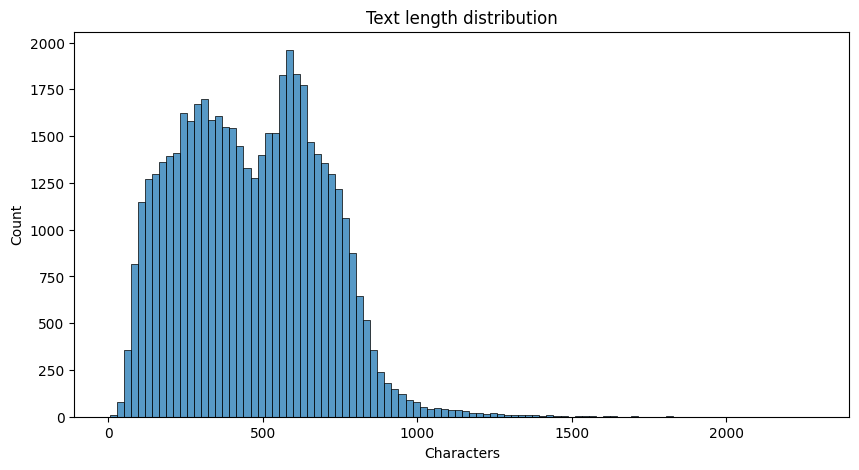

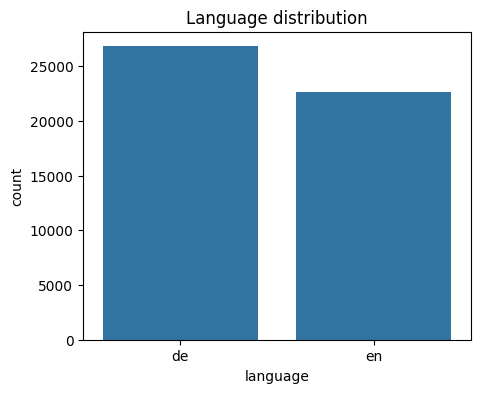

In [7]:
plot_queue_distribution(splits["train"])
plot_priority_distribution(splits["train"])
plot_text_lengths(splits["train"])
plot_language_distribution(splits["train"])

# Label Encoding

In [8]:
queue_enc = LabelEncoder()
priority_enc = LabelEncoder()
type_enc = LabelEncoder()

splits["train"]["queue"] = queue_enc.fit_transform(splits["train"]["queue"])
splits["val"]["queue"] = queue_enc.transform(splits["val"]["queue"])
splits["test"]["queue"] = queue_enc.transform(splits["test"]["queue"])

splits["train"]["priority"] = priority_enc.fit_transform(splits["train"]["priority"])
splits["val"]["priority"] = priority_enc.transform(splits["val"]["priority"])
splits["test"]["priority"] = priority_enc.transform(splits["test"]["priority"])

splits["train"]["type"] = type_enc.fit_transform(splits["train"]["type"])
splits["val"]["type"] = type_enc.transform(splits["val"]["type"])
splits["test"]["type"] = type_enc.transform(splits["test"]["type"])

# Baseline: TF-IDF + Linear model

In [9]:
def build_text(df):

    return (df["subject"].fillna("") + "\n\n" + df["body"].fillna("")).astype(str)


vectorizer = TfidfVectorizer(
    max_features=200_000,
    ngram_range=(1,2),
    min_df=2
)

X_train = vectorizer.fit_transform(build_text(splits["train"]))
X_val = vectorizer.transform(build_text(splits["val"]))
X_test = vectorizer.transform(build_text(splits["test"]))

In [10]:
y_train_queue = splits["train"]["queue"]
y_test_queue = splits["test"]["queue"]

queue_model = LinearSVC()

queue_model.fit(X_train, y_train_queue)

queue_pred = queue_model.predict(X_test)

queue_acc = accuracy_score(y_test_queue, queue_pred)
queue_f1 = f1_score(y_test_queue, queue_pred, average="macro")

print("Queue accuracy:", queue_acc)
print("Queue macro F1:", queue_f1)

Queue accuracy: 0.6914359721547677
Queue macro F1: 0.8939852349524268


In [11]:
priority_model = LinearSVC()

priority_model.fit(X_train, splits["train"]["priority"])

priority_pred = priority_model.predict(X_test)

priority_acc = accuracy_score(
    splits["test"]["priority"],
    priority_pred
)

In [12]:
type_model = LinearSVC()

type_model.fit(X_train, splits["train"]["type"])

type_pred = type_model.predict(X_test)

type_acc = accuracy_score(
    splits["test"]["type"],
    type_pred
)

In [13]:
baseline_score = (
    0.70 * queue_f1
    + 0.15 * priority_acc
    + 0.15 * type_acc
)

print("Baseline Score:", baseline_score)

Baseline Score: 0.8670718402802005


In [14]:
baseline_results = pd.DataFrame({
    "Model": ["TF-IDF + LinearSVC"],
    "Queue MacroF1": [queue_f1],
    "Queue Acc": [queue_acc],
    "Priority Acc": [priority_acc],
    "Type Acc": [type_acc],
    "Final Score": [baseline_score]
})

baseline_results.round(4)

,Model,Queue MacroF1,Queue Acc,Priority Acc,Type Acc,Final Score
0,TF-IDF + LinearSVC,0.894,0.6914,0.7112,0.8974,0.8671


# TF-IDF + LightGBM - финальная модель

In [17]:
import lightgbm as lgb

In [18]:
vectorizer = TfidfVectorizer(
    max_features=300000,
    ngram_range=(1,3),
    min_df=2,
    max_df=0.9,
    sublinear_tf=True
)

X_train = vectorizer.fit_transform(build_text(splits["train"]))

X_val = vectorizer.transform(build_text(splits["val"]))

X_test = vectorizer.transform(build_text(splits["test"]))

In [21]:
queue_model = lgb.LGBMClassifier(
    objective="multiclass",
    num_class=len(queue_enc.classes_),
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=64,
    n_jobs=-1
)

queue_model.fit(
    X_train,
    splits["train"]["queue"],

    eval_set=[(X_val, splits["val"]["queue"])],
    eval_metric="multi_logloss",

    callbacks=[
        lgb.early_stopping(50)
        # lgb.log_evaluation(50)
    ]
)

val_pred = queue_model.predict(X_val)

val_acc = accuracy_score(
    splits["val"]["queue"],
    val_pred
)

val_f1 = f1_score(
    splits["val"]["queue"],
    val_pred,
    average="macro"
)

print("Validation accuracy:", val_acc)
print("Validation macro F1:", val_f1)

queue_pred = queue_model.predict(X_test)

queue_acc = accuracy_score(
    splits["test"]["queue"],
    queue_pred
)

queue_f1 = f1_score(
    splits["test"]["queue"],
    queue_pred,
    average="macro"
)

print("Test accuracy:", queue_acc)
print("Test macro F1:", queue_f1)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 7.719098 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1322540
[LightGBM] [Info] Number of data points in the train set: 49412, number of used features: 39675
[LightGBM] [Info] Start training from score -5.475230
[LightGBM] [Info] Start training from score -5.314887
[LightGBM] [Info] Start training from score -5.339888
[LightGBM] [Info] Start training from score -5.148466
[LightGBM] [Info] Start training from score -5.286488
[LightGBM] [Info] Start training from score -5.327310
[LightGBM] [Info] Start training from score -2.551341
[LightGBM] [Info] Start training from score -5.361211
[LightGBM] [Info] Start training from score -5.278520
[LightGBM] [Info] Start training from score -5.209527
[LightGBM] [Info] Start training from score -2.124394
[LightGBM] [Info] Start training from score -5.247267
[LightGBM] [Info] Start training from score -5.270614
[Li

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Validation accuracy: 0.5488989637305699
Validation macro F1: 0.6751766967257562


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Test accuracy: 0.5470293022502833
Test macro F1: 0.6687054024865764


In [22]:
priority_model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=32,
    n_jobs=-1
)

priority_model.fit(
    X_train,
    splits["train"]["priority"],

    eval_set=[(X_val, splits["val"]["priority"])],
    callbacks=[
        lgb.early_stopping(50)
        # lgb.log_evaluation(50)
    ]
)

priority_val_pred = priority_model.predict(X_val)

priority_val_acc = accuracy_score(
    splits["val"]["priority"],
    priority_val_pred
)

print("Priority val accuracy:", priority_val_acc)

priority_pred = priority_model.predict(X_test)

priority_acc = accuracy_score(
    splits["test"]["priority"],
    priority_pred
)

print("Priority test accuracy:", priority_acc)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 4.809589 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1322540
[LightGBM] [Info] Number of data points in the train set: 49412, number of used features: 39675
[LightGBM] [Info] Start training from score -3.484118
[LightGBM] [Info] Start training from score -1.035367
[LightGBM] [Info] Start training from score -1.569993
[LightGBM] [Info] Start training from score -0.975474
[LightGBM] [Info] Start training from score -3.534856
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[500]	valid_0's multi_logloss: 0.753637


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Priority val accuracy: 0.6625647668393783


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Priority test accuracy: 0.6611623765581998


In [23]:
type_model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=32,
    n_jobs=-1
)

type_model.fit(
    X_train,
    splits["train"]["type"],

    eval_set=[(X_val, splits["val"]["type"])],
    callbacks=[
        lgb.early_stopping(50)
        # lgb.log_evaluation(50)
    ]
)

type_val_pred = type_model.predict(X_val)

type_val_acc = accuracy_score(
    splits["val"]["type"],
    type_val_pred
)

print("Type val accuracy:", type_val_acc)

type_pred = type_model.predict(X_test)

type_acc = accuracy_score(
    splits["test"]["type"],
    type_pred
)

print("Type test accuracy:", type_acc)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 4.943618 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1322540
[LightGBM] [Info] Number of data points in the train set: 49412, number of used features: 39675
[LightGBM] [Info] Start training from score -2.512899
[LightGBM] [Info] Start training from score -1.150873
[LightGBM] [Info] Start training from score -1.807959
[LightGBM] [Info] Start training from score -1.487409
[LightGBM] [Info] Start training from score -1.548056
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[494]	valid_0's multi_logloss: 0.265925


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Type val accuracy: 0.875809585492228


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Type test accuracy: 0.8811720900113323


In [24]:
lgb_score = (
    0.70 * queue_f1
    + 0.15 * priority_acc
    + 0.15 * type_acc
)

print("LightGBM Final Score:", lgb_score)

LightGBM Final Score: 0.6994439517260332


In [25]:
lgb_results = pd.DataFrame({
    "Model": ["TFIDF + LightGBM"],
    "Queue MacroF1": [queue_f1],
    "Queue Acc": [queue_acc],
    "Priority Acc": [priority_acc],
    "Type Acc": [type_acc],
    "Final Score": [lgb_score]
})

lgb_results.round(4)

,Model,Queue MacroF1,Queue Acc,Priority Acc,Type Acc,Final Score
0,TFIDF + LightGBM,0.6687,0.547,0.6612,0.8812,0.6994


Confidance analysis

In [27]:
probs = queue_model.predict_proba(X_test)

conf = probs.max(axis=1)

preds = probs.argmax(axis=1)

true = splits["test"]["queue"].values

print(true)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[49 16 28 ... 10 39  6]


Coverage analysis

In [28]:
coverages = np.linspace(0.5,1.0,11)

accs=[]

order = np.argsort(-conf)

for c in coverages:

    k = int(len(conf)*c)

    idx = order[:k]

    acc = accuracy_score(true[idx], preds[idx])

    accs.append(acc)

Confidance график

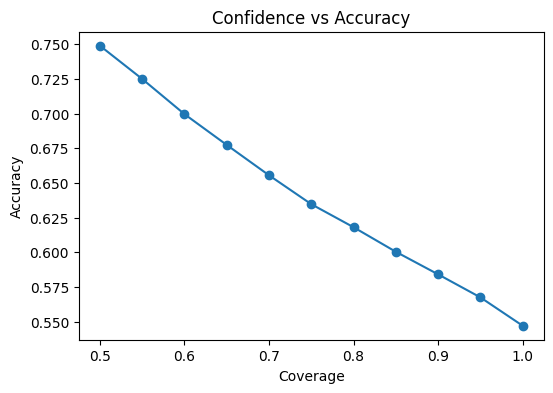

In [29]:
plt.figure(figsize=(6,4))

plt.plot(coverages, accs, marker="o")

plt.xlabel("Coverage")
plt.ylabel("Accuracy")

plt.title("Confidence vs Accuracy")

plt.show()

In [30]:
final_results = pd.concat([
    baseline_results,
    lgb_results
])

final_results.round(4)

,Model,Queue MacroF1,Queue Acc,Priority Acc,Type Acc,Final Score
0,TF-IDF + LinearSVC,0.8940,0.6914,0.7112,0.8974,0.8671
0,TFIDF + LightGBM,0.6687,0.5470,0.6612,0.8812,0.6994
